# HMS - Harmful Brain Activity Classification
## PyTorch Pipeline: nnAudio (Trainable STFT) + EfficientNet + GRU

This notebook implements a full training and inference pipeline that:
1. Loads **raw EEG** signals (no pre-computed spectrograms)
2. Computes spectrograms **on-the-fly** using nnAudio with a trainable STFT
3. Extracts features using a pretrained **EfficientNetV2-B2** backbone
4. Models temporal evolution with a **Bidirectional GRU**
5. Classifies into 6 harmful brain activity categories

### Pipeline
```
Raw EEG [batch, 16, 10000]
    ↓
nnAudio STFT (trainable)
    ↓
Log + Normalize
    ↓
Mono → 3 channel
    ↓
EfficientNet backbone (remove classification head)
    ↓
Pool over frequency, keep time axis
    ↓
GRU reads across time
    ↓
Softmax → 6 classes
```

### Reference
This notebook is the PyTorch counterpart of the Keras starter notebook.
Both can be ensembled at the prediction level (numpy arrays).

# 🛠 | Install Libraries

Run this cell once to install required packages.

In [1]:
# All dependencies are installed via requirements.txt:
#   pip install -r requirements.txt
#
# If running inside the notebook without requirements.txt:
# !pip install -r requirements.txt

# 📚 | Import Libraries

In [2]:
import os
import math
import random
import gc
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import timm
from nnAudio.features import STFT

from sklearn.model_selection import StratifiedGroupKFold
import joblib

print(f"PyTorch: {torch.__version__}")
print(f"timm: {timm.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
timm: 1.0.25
CUDA available: True
GPU: Tesla T4


# ⚙️ | Configuration

Mirrors the Keras notebook's CFG class with additions for STFT, GRU,
and differential learning rates.

In [3]:
class CFG:
    # --- General ---
    verbose = 1
    seed = 42
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- Data ---
    num_classes = 6
    class_names = ["Seizure", "LPD", "GPD", "LRDA", "GRDA", "Other"]
    label2name = dict(enumerate(class_names))
    name2label = {v: k for k, v in label2name.items()}

    # --- EEG ---
    eeg_sample_rate = 200       # Hz
    eeg_duration = 50           # seconds
    eeg_samples = eeg_sample_rate * eeg_duration  # 10000
    num_bipolar_channels = 16   # 4 chains x 4 pairs

    # --- nnAudio STFT ---
    n_fft = 128
    hop_length = 128             # smaller hop → more time frames for GRU
    trainable_stft = True

    # --- Model ---
    backbone = "tf_efficientnetv2_b2"  # timm model name (same arch as Keras preset)
    gru_hidden = 128
    gru_layers = 2
    dropout = 0.3

    # --- Training ---
    epochs = 13                 # same as Keras notebook
    batch_size = 16             # same as Keras notebook
    lr_backbone = 1e-4          # pretrained — learn slowly
    lr_stft = 1e-3              # near-random — learn fast
    lr_head = 5e-4              # new layers — learn medium-fast
    lr_mode = "cos"             # same as Keras notebook
    weight_decay = 1e-4
    max_grad_norm = 1.0         # gradient clipping for GRU stability
    use_amp = False              # mixed precision (like Keras mixed_float16)
    num_workers = 4             # dataloader workers (set to 0 if issues on Windows)
    fold = 0                    # which fold to validate on
    n_folds = 2

print(f"Device: {CFG.device}")
print(f"Mixed precision: {CFG.use_amp}")
print(f"EEG samples per clip: {CFG.eeg_samples}")
print(f"STFT: n_fft={CFG.n_fft}, hop_length={CFG.hop_length}")
expected_time_frames = (CFG.eeg_samples - CFG.n_fft) // CFG.hop_length + 1
expected_freq_bins = CFG.n_fft // 2 + 1
print(f"Expected time frames after STFT: {expected_time_frames}")
print(f"Expected freq bins per channel: {expected_freq_bins}")
print(f"Expected spectrogram shape: [{expected_freq_bins * 4}, {expected_time_frames}]")

Device: cuda
Mixed precision: False
EEG samples per clip: 10000
STFT: n_fft=128, hop_length=128
Expected time frames after STFT: 78
Expected freq bins per channel: 65
Expected spectrogram shape: [260, 78]


# ♻️ | Reproducibility

Sets value for random seed to produce similar result in each run.

In [4]:
def set_seed(seed=CFG.seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# 📁 | Dataset Paths

**Important**: Adjust `BASE_PATH` to match your data location.
The Keras notebook uses `project_root.parent.parent / "data" / "data"`.

In [5]:
project_root = Path.cwd()

# =============================================
# ADJUST THIS PATH TO MATCH YOUR DATA LOCATION
# This matches the Keras notebook's path structure
# =============================================
BASE_PATH = project_root.parent.parent.parent / "data" / "data"

# Output directories
MODELS_DIR = project_root / "models"
RESULTS_DIR = project_root / "results"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verify
print("=" * 60)
print(f"Project root: {project_root}")
print(f"Data path:    {BASE_PATH}")
print(f"Data exists:  {BASE_PATH.exists()}")

if BASE_PATH.exists():
    for name in ["train.csv", "test.csv", "train_eegs", "test_eegs"]:
        path = BASE_PATH / name
        status = "✓" if path.exists() else "✗"
        print(f"  {status} {name}")
print("=" * 60)

# Pre-processed bipolar EEG files (.npy)
PROCESSED_DIR = BASE_PATH / "processed" / "bipolar_eegs"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Processed EEGs: {PROCESSED_DIR}")


Project root: /home/littl/ECE247A_Final_Project/AL/AL_model
Data path:    /home/littl/data/data
Data exists:  True
  ✓ train.csv
  ✓ test.csv
  ✓ train_eegs
  ✓ test_eegs
Processed EEGs: /home/littl/data/data/processed/bipolar_eegs


# 📖 | Metadata

We only need the EEG paths (not spectrogram paths) since nnAudio
generates spectrograms on-the-fly from raw EEG.

In [6]:
# --- Train ---
df = pd.read_csv(BASE_PATH / "train.csv")
df["eeg_path"] = df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "train_eegs" / f"{x}.parquet")
)
df["class_name"] = df["expert_consensus"].copy()
df["class_label"] = df["expert_consensus"].map(CFG.name2label)

print(f"Train CSV rows: {len(df)}")
print(f"Unique EEG files: {df['eeg_id'].nunique()}")
print(f"Unique patients: {df['patient_id'].nunique()}")
display(df.head(2))

# --- Test ---
test_df = pd.read_csv(BASE_PATH / "test.csv")
test_df["eeg_path"] = test_df["eeg_id"].apply(
    lambda x: str(BASE_PATH / "test_eegs" / f"{x}.parquet")
)

print(f"\nTest CSV rows: {len(test_df)}")
display(test_df.head(2))

Train CSV rows: 106800
Unique EEG files: 17089
Unique patients: 1950


,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote,eeg_path,class_name,class_label
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,Seizure,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0,/home/littl/data/data/train_eegs/1628180742.pa...,Seizure,0



Test CSV rows: 1


,spectrogram_id,eeg_id,patient_id,eeg_path
0,853520,3911565283,6885,/home/littl/data/data/test_eegs/3911565283.par...


# 🧠 | Bipolar Banana Montage

The standard 10-20 system has 19 electrodes. We compute the **double banana bipolar montage**,
which subtracts adjacent electrodes to produce 16 bipolar channels in 4 chains:

| Chain | Pairs | Region |
|-------|-------|--------|
| LL (Left Lateral) | Fp1-F7, F7-T3, T3-T5, T5-O1 | Left temporal |
| RL (Right Lateral) | Fp2-F8, F8-T4, T4-T6, T6-O2 | Right temporal |
| LP (Left Parasagittal) | Fp1-F3, F3-C3, C3-P3, P3-O1 | Left central |
| RP (Right Parasagittal) | Fp2-F4, F4-C4, C4-P4, P4-O2 | Right central |

In [7]:
BIPOLAR_MONTAGE = {
    "LL": [("Fp1", "F7"), ("F7", "T3"), ("T3", "T5"), ("T5", "O1")],
    "RL": [("Fp2", "F8"), ("F8", "T4"), ("T4", "T6"), ("T6", "O2")],
    "LP": [("Fp1", "F3"), ("F3", "C3"), ("C3", "P3"), ("P3", "O1")],
    "RP": [("Fp2", "F4"), ("F4", "C4"), ("C4", "P4"), ("P4", "O2")],
}

BIPOLAR_PAIRS = []
CHAIN_ORDER = ["LL", "RL", "LP", "RP"]
for chain_name in CHAIN_ORDER:
    BIPOLAR_PAIRS.extend(BIPOLAR_MONTAGE[chain_name])

print(f"Total bipolar channels: {len(BIPOLAR_PAIRS)}")
for i, (a, b) in enumerate(BIPOLAR_PAIRS):
    chain = CHAIN_ORDER[i // 4]
    print(f"  Ch {i:2d} ({chain}): {a} - {b}")

# Verify electrode names exist in an actual EEG file
sample_eeg = pd.read_parquet(df.iloc[0]["eeg_path"])
eeg_columns = sample_eeg.columns.tolist()
print(f"\nEEG file columns: {eeg_columns}")
needed = set()
for a, b in BIPOLAR_PAIRS:
    needed.add(a)
    needed.add(b)
missing = needed - set(eeg_columns)
if missing:
    print(f"⚠ WARNING: Missing electrodes: {missing}")
    print("You may need to adjust electrode names in BIPOLAR_MONTAGE")
else:
    print("✓ All required electrodes found in EEG data")

Total bipolar channels: 16
  Ch  0 (LL): Fp1 - F7
  Ch  1 (LL): F7 - T3
  Ch  2 (LL): T3 - T5
  Ch  3 (LL): T5 - O1
  Ch  4 (RL): Fp2 - F8
  Ch  5 (RL): F8 - T4
  Ch  6 (RL): T4 - T6
  Ch  7 (RL): T6 - O2
  Ch  8 (LP): Fp1 - F3
  Ch  9 (LP): F3 - C3
  Ch 10 (LP): C3 - P3
  Ch 11 (LP): P3 - O1
  Ch 12 (RP): Fp2 - F4
  Ch 13 (RP): F4 - C4
  Ch 14 (RP): C4 - P4
  Ch 15 (RP): P4 - O2

EEG file columns: ['Fp1', 'F3', 'C3', 'P3', 'F7', 'T3', 'T5', 'O1', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'F8', 'T4', 'T6', 'O2', 'EKG']
✓ All required electrodes found in EEG data


# 🔄 | Pre-process EEG → Bipolar .npy

One-time conversion: read each raw EEG parquet, compute bipolar montage,
normalize, and save as a lightweight `.npy` file (~640 KB each).
This runs once — subsequent runs skip existing files.

**Why?** Loading a 640 KB numpy array is ~100× faster than parsing a
multi-MB parquet file + computing the montage every epoch.

In [8]:
def preprocess_eeg(row_idx, dataframe, split="train"):
    """Convert one EEG parquet → pre-processed bipolar .npy file."""
    row = dataframe.iloc[row_idx]
    eeg_id = row["eeg_id"]
    output_path = PROCESSED_DIR / f"{eeg_id}.npy"

    if output_path.exists():
        return  # skip if already done

    # Load raw EEG
    eeg_df = pd.read_parquet(row["eeg_path"])

    # Extract window
    offset = int(row.get("eeg_label_offset_seconds", 0))
    start = offset * CFG.eeg_sample_rate
    end = start + CFG.eeg_samples
    window = eeg_df.iloc[start:end]

    # Pad if needed
    if len(window) < CFG.eeg_samples:
        pad = pd.DataFrame(
            np.zeros((CFG.eeg_samples - len(window), len(window.columns))),
            columns=window.columns,
        )
        window = pd.concat([window, pad], ignore_index=True)

    # Compute bipolar montage
    cols = window.columns.tolist()
    bipolar = []
    for (a, b) in BIPOLAR_PAIRS:
        if a in cols and b in cols:
            sig = window[a].values - window[b].values
        else:
            sig = np.zeros(CFG.eeg_samples, dtype=np.float32)
        bipolar.append(sig)
    bipolar = np.stack(bipolar, axis=0).astype(np.float32)  # [16, 10000]

    # Clean
    bipolar = np.nan_to_num(bipolar, nan=0.0)
    bipolar = np.clip(bipolar, -1024, 1024)

    # Normalize per channel
    mean = bipolar.mean(axis=1, keepdims=True)
    std = bipolar.std(axis=1, keepdims=True) + 1e-6
    bipolar = (bipolar - mean) / std

    np.save(str(output_path), bipolar)


# --- Process training EEGs ---
# We only need EEGs for the sampled rows (one per spectrogram_id)
# Full sample_df isn't created yet, so process all unique eeg_ids from df
unique_train = df.drop_duplicates(subset="eeg_id").reset_index(drop=True)
print(f"Processing {len(unique_train)} unique training EEG files...")
_ = joblib.Parallel(n_jobs=-1, backend="loky")(
    joblib.delayed(preprocess_eeg)(i, unique_train, "train")
    for i in tqdm(range(len(unique_train)))
)

# --- Process test EEGs ---
print(f"Processing {len(test_df)} test EEG files...")
_ = joblib.Parallel(n_jobs=-1, backend="loky")(
    joblib.delayed(preprocess_eeg)(i, test_df, "test")
    for i in tqdm(range(len(test_df)))
)

print(f"✓ Pre-processing complete. Files saved to: {PROCESSED_DIR}")
print(f"  Sample file size: {list(PROCESSED_DIR.glob('*.npy'))[0].stat().st_size / 1024:.0f} KB")

Processing 17089 unique training EEG files...


  0%|          | 0/17089 [00:00<?, ?it/s]

Processing 1 test EEG files...


  0%|          | 0/1 [00:00<?, ?it/s]

✓ Pre-processing complete. Files saved to: /home/littl/data/data/processed/bipolar_eegs
  Sample file size: 625 KB


# 🍚 | PyTorch Dataset (Fast .npy Loading)

Loads pre-processed bipolar `.npy` files — no parquet parsing, no cache bloat.
Each `__getitem__` call is a single `np.load()` (~0.5 ms vs ~50 ms for parquet).

**No spectrogram here** — nnAudio computes that inside the model on GPU.

In [9]:
class HMSDataset(Dataset):
    def __init__(self, df, mode="train", augment=False):
        self.df = df.reset_index(drop=True)
        self.mode = mode
        self.augment = augment
        # Pre-build .npy paths — one per sample
        self.npy_paths = [
            str(PROCESSED_DIR / f"{eid}.npy")
            for eid in self.df["eeg_id"].values
        ]

    def __len__(self):
        return len(self.df)

    def _augment_eeg(self, eeg):
        """
        Augmentations on raw EEG signal.
        Applied on every sample (matching Keras notebook
        where augmenters run unconditionally).
        """
        # Gaussian noise
        noise_std = np.random.uniform(0.005, 0.015)
        eeg = eeg + np.random.normal(0, noise_std, eeg.shape).astype(np.float32)

        # Random amplitude scaling
        scale = np.random.uniform(0.8, 1.2)
        eeg = eeg * scale

        # Random channel dropout (zero out 1-2 channels)
        if random.random() < 0.3:
            n_drop = random.randint(1, 2)
            drop_idx = random.sample(range(16), n_drop)
            eeg[drop_idx] = 0.0

        return eeg

    def __getitem__(self, idx):
        # Fast: single numpy load (~0.5 ms)
        bipolar = np.load(self.npy_paths[idx])  # [16, 10000] float32

        if self.augment:
            bipolar = self._augment_eeg(bipolar)

        eeg_tensor = torch.tensor(bipolar, dtype=torch.float32)

        if self.mode == "test":
            return eeg_tensor

        # One-hot label
        label = torch.zeros(CFG.num_classes, dtype=torch.float32)
        label[int(self.df.iloc[idx]["class_label"])] = 1.0

        return eeg_tensor, label

## MixUp Augmentation

The Keras notebook applies MixUp via `keras_cv.layers.MixUp(alpha=2.0)` on every batch.
Here's the PyTorch equivalent, applied during training.

In [10]:
def mixup(data, targets, alpha=2.0):
    """
    MixUp augmentation — blends pairs of samples and labels.
    Equivalent to keras_cv.layers.MixUp(alpha=2.0).

    Args:
        data: [batch, ...] input tensors
        targets: [batch, num_classes] one-hot labels
        alpha: Beta distribution parameter (higher = more mixing)
    Returns:
        mixed_data, mixed_targets
    """
    indices = torch.randperm(data.size(0), device=data.device)
    lam = torch.distributions.Beta(alpha, alpha).sample().to(data.device)
    mixed_data = lam * data + (1 - lam) * data[indices]
    mixed_targets = lam * targets + (1 - lam) * targets[indices]
    return mixed_data, mixed_targets

# 🤖 | Model Architecture

4 components:
1. **nnAudio STFT**: Raw EEG → spectrogram (trainable, on GPU)
2. **EfficientNetV2-B2**: Feature extraction (pretrained ImageNet, same as Keras preset)
3. **Frequency pooling**: Collapse frequency axis, preserve time axis
4. **Bidirectional GRU**: Model temporal evolution → classify

In [11]:
class SpectrogramModel(nn.Module):
    def __init__(self, cfg=CFG):
        super().__init__()
        self.cfg = cfg

        # ==============================================================
        # Stage 1: nnAudio STFT — raw EEG → spectrogram on GPU
        # (replaces the entire parquet→npy conversion + decode_signal)
        # ==============================================================
        self.stft = STFT(
            n_fft=cfg.n_fft,
            hop_length=cfg.hop_length,
            sr=cfg.eeg_sample_rate,
            trainable=cfg.trainable_stft,
            output_format="Magnitude",
        )
        self.log_eps = 1e-6

        # ==============================================================
        # Stage 2: CNN backbone — same architecture as Keras preset
        # "efficientnetv2_b2_imagenet" in KerasCV = "tf_efficientnetv2_b2" in timm
        # ==============================================================
        self.backbone = timm.create_model(
            cfg.backbone,
            pretrained=True,
            in_chans=3,
            features_only=True,
        )
        # Determine backbone output channels from a dummy forward pass
        with torch.no_grad():
            dummy = torch.randn(1, 3, 64, 64)
            backbone_out = self.backbone(dummy)
        backbone_channels = backbone_out[-1].shape[1]
        print(f"Backbone last feature map channels: {backbone_channels}")

        # ==============================================================
        # Stage 3: GRU — reads CNN features across time axis
        # (this is the key addition over the Keras notebook)
        # ==============================================================
        self.gru = nn.GRU(
            input_size=backbone_channels,
            hidden_size=cfg.gru_hidden,
            num_layers=cfg.gru_layers,
            batch_first=True,
            bidirectional=True,
            dropout=cfg.dropout if cfg.gru_layers > 1 else 0.0,
        )

        # ==============================================================
        # Stage 4: Classification head
        # (replaces Keras preset's built-in Dense + Softmax)
        # ==============================================================
        gru_out_dim = cfg.gru_hidden * 2  # bidirectional doubles output
        self.head = nn.Sequential(
            nn.Dropout(cfg.dropout),
            nn.Linear(gru_out_dim, 128),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(128, cfg.num_classes),
        )

    def make_spectrograms(self, eeg):
        """
        Raw EEG → 4-chain spectrogram (replaces parquet→npy conversion).
        Input:  [batch, 16, 10000]
        Output: [batch, freq_bins*4, time_frames]
        """
        batch, channels, time = eeg.shape

        # STFT all channels at once: [batch*16, 10000] → [batch*16, freq, time]
        x = eeg.reshape(batch * channels, time)
        x = self.stft(x)
        freq_bins, time_frames = x.shape[1], x.shape[2]

        # Reshape: [batch, 16, freq, time]
        x = x.reshape(batch, channels, freq_bins, time_frames)

        # Average within each chain (4 channels per chain)
        # Channels 0-3=LL, 4-7=RL, 8-11=LP, 12-15=RP
        ll = x[:, 0:4, :, :].mean(dim=1)
        rl = x[:, 4:8, :, :].mean(dim=1)
        lp = x[:, 8:12, :, :].mean(dim=1)
        rp = x[:, 12:16, :, :].mean(dim=1)

        # Concatenate along frequency: [batch, freq*4, time]
        return torch.cat([ll, rl, lp, rp], dim=1)

    def process_spectrogram(self, spec):
        """
        Log + normalize + 3-channel conversion.
        (Equivalent to Keras notebook's decode_signal: log → normalize → tile)
        Input:  [batch, freq, time]
        Output: [batch, 3, freq, time]
        """
        # Log spectrogram (like tf.clip_by_value + tf.math.log in Keras)
        x = torch.log(spec.clamp(min=self.log_eps))

        # Normalize (like sig -= mean; sig /= std in Keras)
        mean = x.mean(dim=(1, 2), keepdim=True)
        std = x.std(dim=(1, 2), keepdim=True) + 1e-6
        x = (x - mean) / std

        # Mono → 3ch (like tf.tile(sig[..., None], [1, 1, 3]) in Keras)
        return x.unsqueeze(1).repeat(1, 3, 1, 1)

    def forward(self, eeg):
        """
        Full pipeline: raw EEG → class probabilities.
        Input:  [batch, 16, 10000]
        Output: [batch, 6]
        """
        # Stage 1: EEG → spectrogram
        spec = self.make_spectrograms(eeg)
        img = self.process_spectrogram(spec)

        # Stage 2: CNN features
        features = self.backbone(img)
        fmap = features[-1]              # [batch, C, H', W']

        # Pool over frequency (H'), keep time (W')
        # (Keras notebook does GlobalAveragePooling2D which kills BOTH axes;
        #  we only kill frequency to preserve time for GRU)
        x = fmap.mean(dim=2)             # [batch, C, W']
        x = x.permute(0, 2, 1)           # [batch, W', C] for GRU

        # Stage 3: GRU reads across time
        x=x.float()
        x, _ = self.gru(x)               # [batch, W', hidden*2]
        x = x[:, -1, :]                  # last time step: [batch, hidden*2]

        # Stage 4: Classify
        logits = self.head(x)
        return F.softmax(logits, dim=1)

## Model Sanity Check

Verify shapes at each stage with dummy data.

In [12]:
model = SpectrogramModel(CFG).to(CFG.device)

dummy = torch.randn(2, CFG.num_bipolar_channels, CFG.eeg_samples).to(CFG.device)
with torch.no_grad():
    spec = model.make_spectrograms(dummy)
    print(f"After STFT:          {spec.shape}")
    img = model.process_spectrogram(spec)
    print(f"After log+norm+3ch:  {img.shape}")
    feats = model.backbone(img)
    print(f"After CNN backbone:  {feats[-1].shape}")
    pooled = feats[-1].mean(dim=2)
    print(f"After freq pooling:  {pooled.shape}")
    out = model(dummy)
    print(f"Final output:        {out.shape}")
    print(f"Prob sum (expect 1): {out.sum(dim=1).cpu().numpy()}")

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {train_params:,}")

del model, dummy
torch.cuda.empty_cache()
gc.collect()

STFT kernels created, time used = 0.0027 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Backbone last feature map channels: 208


AcceleratorError: CUDA error: out of memory
Search for `cudaErrorMemoryAllocation' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# 🔪 | Data Split

**Identical to Keras notebook**: `StratifiedGroupKFold` with 5 folds,
grouped by `patient_id` to prevent leakage, stratified by `class_label`.

In [ ]:
sgkf = StratifiedGroupKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)

df["fold"] = -1
df.reset_index(drop=True, inplace=True)
for fold, (train_idx, valid_idx) in enumerate(
    sgkf.split(df, y=df["class_label"], groups=df["patient_id"])
):
    df.loc[valid_idx, "fold"] = fold

print("Samples per fold and class:")
display(df.groupby(["fold", "class_name"])[["eeg_id"]].count().unstack())

Samples per fold and class:


eeg_id                                 
class_name    GPD   GRDA   LPD  LRDA Other Seizure
fold                                              
0            5976  10163  6111  6741  8822   11065
1           10726   8698  8745  9899  9986    9868

## Build Train & Validation Sets

Same sampling strategy as Keras notebook: one row per `spectrogram_id`.

In [ ]:
sample_df = df.groupby("spectrogram_id").head(1).reset_index(drop=True)
train_df = sample_df[sample_df.fold != CFG.fold].reset_index(drop=True)
valid_df = sample_df[sample_df.fold == CFG.fold].reset_index(drop=True)
print(f"# Num Train: {len(train_df)} | Num Valid: {len(valid_df)}")

# Datasets
train_dataset = HMSDataset(train_df, mode="train", augment=True)
valid_dataset = HMSDataset(valid_df, mode="valid", augment=False)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=True,              # same as Keras drop_remainder=True
    persistent_workers=True if CFG.num_workers > 0 else False,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=False,
    persistent_workers=True if CFG.num_workers > 0 else False,
)

print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")

# Num Train: 5721 | Num Valid: 5417
Train batches: 357 | Valid batches: 339


## Dataset Sanity Check

EEG batch:   torch.Size([16, 16, 10000])
Label batch: torch.Size([16, 6])


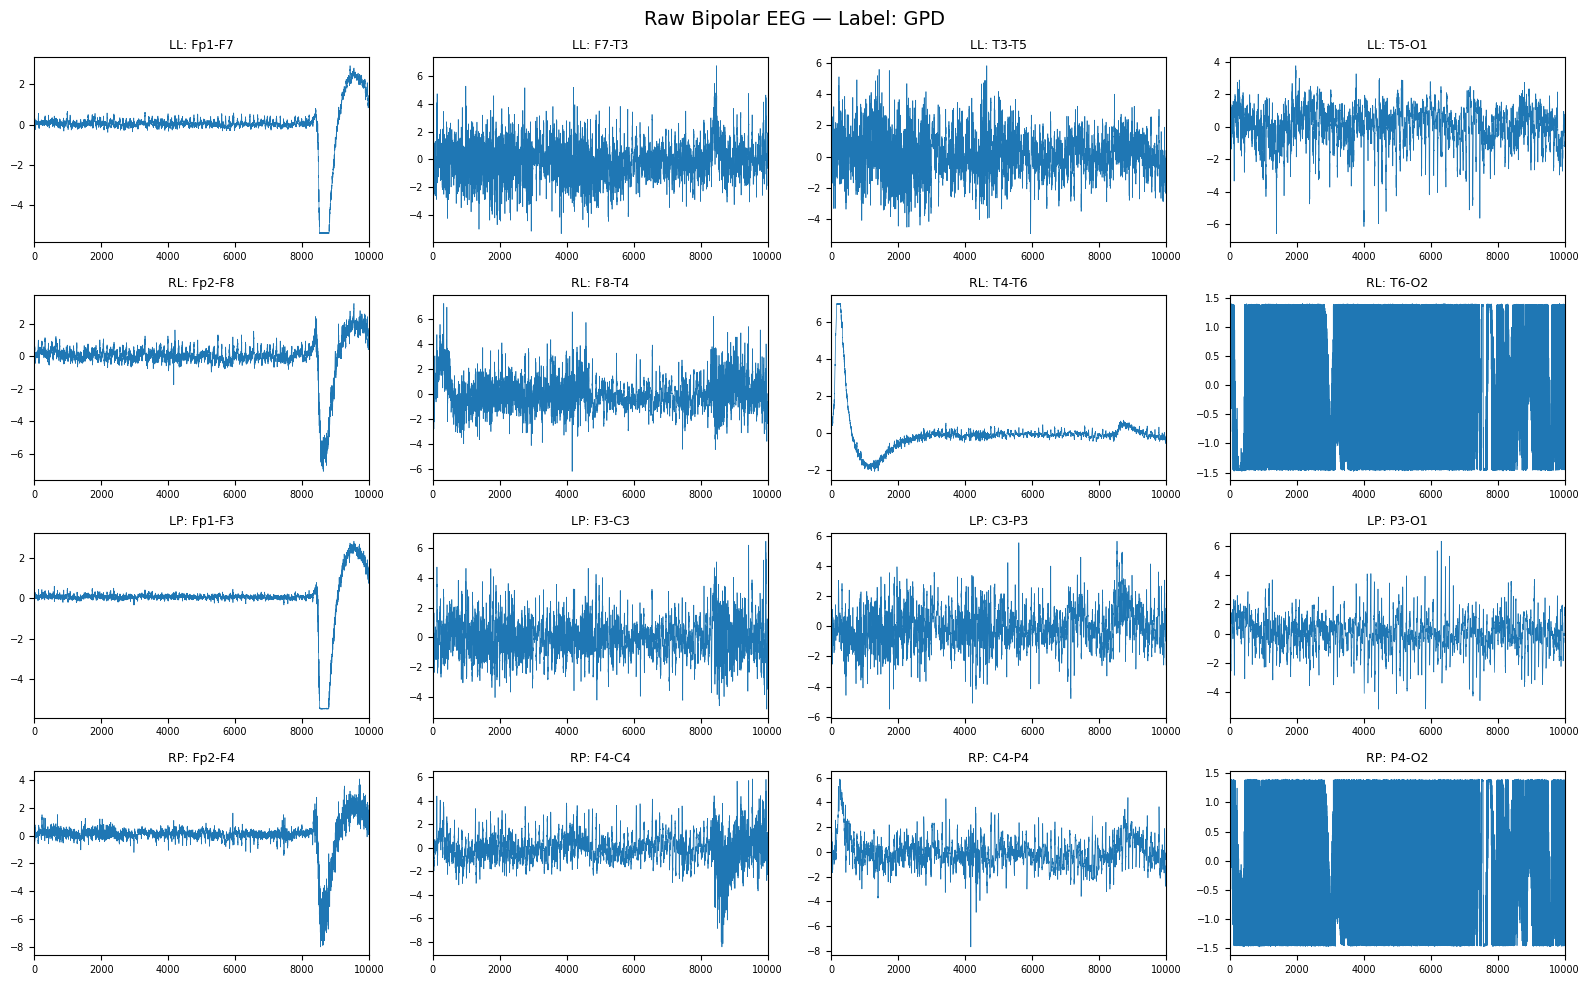

In [ ]:
sample_eeg, sample_label = next(iter(train_loader))
print(f"EEG batch:   {sample_eeg.shape}")    # [32, 16, 10000]
print(f"Label batch: {sample_label.shape}")   # [32, 6]

# Plot raw EEG channels for first sample
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
eeg_np = sample_eeg[0].numpy()
label_name = CFG.label2name[sample_label[0].argmax().item()]

for i in range(16):
    ax = axes[i // 4][i % 4]
    ax.plot(eeg_np[i], linewidth=0.5)
    chain = CHAIN_ORDER[i // 4]
    pair = BIPOLAR_PAIRS[i]
    ax.set_title(f"{chain}: {pair[0]}-{pair[1]}", fontsize=9)
    ax.set_xlim(0, CFG.eeg_samples)
    ax.tick_params(labelsize=7)

fig.suptitle(f"Raw Bipolar EEG — Label: {label_name}", fontsize=14)
plt.tight_layout()
plt.show()

# 🔍 | Loss Function

KL Divergence — same as `keras.losses.KLDivergence()` in the Keras notebook.

In [ ]:
class KLDivLoss(nn.Module):
    """
    KL Divergence loss.
    PyTorch KLDivLoss expects log-probabilities, so we log() our softmax output.
    """
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.KLDivLoss(reduction="batchmean")

    def forward(self, preds, targets):
        return self.loss_fn(torch.log(preds.clamp(min=1e-8)), targets)

criterion = KLDivLoss()

# ⚓ | Optimizer & LR Schedule

**Differential learning rates** — the Keras notebook uses a single LR for everything.
Here we use separate rates because our model has components at different training maturity:
- STFT: learning from scratch → highest LR
- Backbone: pretrained ImageNet → lowest LR
- GRU + head: new layers → medium LR

The schedule shape matches the Keras notebook: linear warmup → cosine decay.

STFT kernels created, time used = 0.0021 seconds


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.
/var/tmp/ipykernel_371875/3681486524.py:33: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  _sched.step()


Backbone last feature map channels: 208


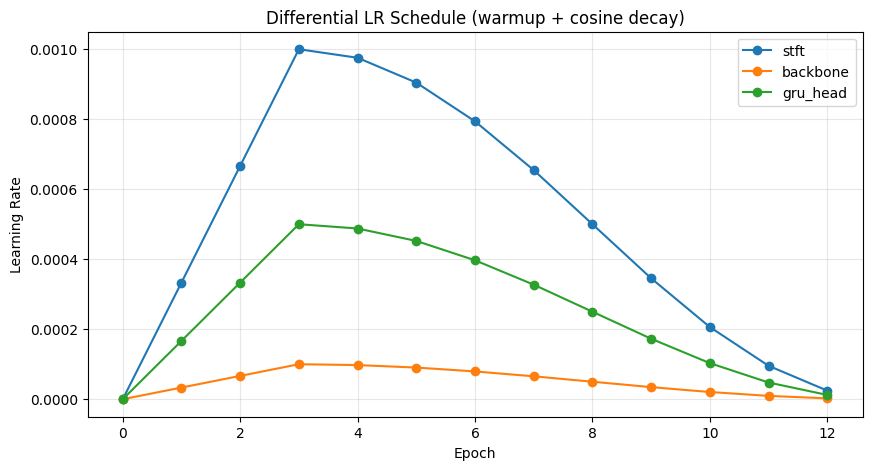

4413

In [ ]:
def build_optimizer(model, cfg=CFG):
    """AdamW with differential learning rates per component."""
    return torch.optim.AdamW([
        {"params": model.stft.parameters(), "lr": cfg.lr_stft, "name": "stft"},
        {"params": model.backbone.parameters(), "lr": cfg.lr_backbone, "name": "backbone"},
        {"params": list(model.gru.parameters()) + list(model.head.parameters()),
         "lr": cfg.lr_head, "name": "gru_head"},
    ], weight_decay=cfg.weight_decay)


def get_cosine_schedule(optimizer, epochs, warmup_epochs=3):
    """
    Cosine annealing with linear warmup.
    Matches the Keras notebook's get_lr_callback with mode='cos'.
    """
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / warmup_epochs
        progress = (epoch - warmup_epochs) / (epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# --- Visualize LR schedule ---
_model = SpectrogramModel(CFG).to(CFG.device)
_opt = build_optimizer(_model)
_sched = get_cosine_schedule(_opt, CFG.epochs)

lrs = {pg["name"]: [] for pg in _opt.param_groups}
for epoch in range(CFG.epochs):
    for pg in _opt.param_groups:
        lrs[pg["name"]].append(pg["lr"])
    _sched.step()

plt.figure(figsize=(10, 5))
for name, lr_list in lrs.items():
    plt.plot(lr_list, marker="o", label=name)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Differential LR Schedule (warmup + cosine decay)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

del _model, _opt, _sched
torch.cuda.empty_cache()
gc.collect()

# 🚂 | Training & Validation Functions

Includes:
- **Mixed precision** (`autocast` + `GradScaler`) — PyTorch equivalent of Keras `mixed_float16`
- **MixUp** on every training batch — matches Keras notebook's always-on augmentation
- **Gradient clipping** — essential for GRU stability

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, cfg=CFG):
    """Train one epoch with MixUp."""
    model.train()
    scaler = GradScaler(enabled=cfg.use_amp)
    running_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch+1}/{cfg.epochs}")
    for eeg, labels in pbar:
        eeg = eeg.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # MixUp (applied every batch, matching Keras notebook)
        eeg, labels = mixup(eeg, labels, alpha=2.0)

        # Forward
        with autocast(enabled=cfg.use_amp):
            preds = model(eeg)
            loss = criterion(preds, labels)

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.max_grad_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        num_batches += 1

        # GPU monitoring in progress bar
        gpu_gb = torch.cuda.memory_allocated() / 1e9
        pbar.set_postfix({
            "loss": f"{running_loss / num_batches:.4f}",
            "gpu": f"{gpu_gb:.1f}GB"
        })

    return running_loss / num_batches


@torch.no_grad()
def validate(model, loader, criterion, device, epoch, cfg=CFG):
    """Validate one epoch."""
    model.eval()
    running_loss = 0.0
    num_batches = 0

    pbar = tqdm(loader, desc=f"Valid Epoch {epoch+1}/{cfg.epochs}")
    for eeg, labels in pbar:
        eeg = eeg.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=cfg.use_amp):
            preds = model(eeg)
            loss = criterion(preds, labels)

        running_loss += loss.item()
        num_batches += 1
        pbar.set_postfix({"val_loss": f"{running_loss / num_batches:.4f}"})

    return running_loss / num_batches

# 🏋️ | Training Loop

Equivalent to Keras notebook's `model.fit()` with `ModelCheckpoint` callback.

## GPU Memory Check

Run a single forward+backward pass to verify everything fits in VRAM
before committing to the full training loop.

In [ ]:
def check_gpu_fit(model, cfg):
    """Test one forward+backward to verify GPU memory is sufficient."""
    model.train()
    torch.cuda.reset_peak_memory_stats()

    dummy = torch.randn(cfg.batch_size, cfg.num_bipolar_channels, cfg.eeg_samples).to(cfg.device)
    labels = torch.randn(cfg.batch_size, cfg.num_classes).softmax(dim=1).to(cfg.device)

    try:
        preds = model(dummy)
        loss = criterion(preds, labels)
        loss.backward()
        model.zero_grad()

        peak = torch.cuda.max_memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_mem / 1e9
        print(f"✓ Forward+backward passed")
        print(f"  Peak GPU: {peak:.2f} GB / {total:.2f} GB ({peak/total*100:.0f}%)")
        if peak / total > 0.85:
            print(f"  ⚠ Tight fit — consider reducing batch_size")
        return True
    except RuntimeError as e:
        print(f"✗ OOM — reduce batch_size or n_fft")
        print(f"  Error: {e}")
        return False
    finally:
        del dummy, labels
        gc.collect()
        torch.cuda.empty_cache()

# Run check with the model from sanity check cell
# (model is re-created in training loop, this is just a pre-flight test)
_test_model = SpectrogramModel(CFG).to(CFG.device)
gpu_ok = check_gpu_fit(_test_model, CFG)
del _test_model
gc.collect()
torch.cuda.empty_cache()

if not gpu_ok:
    print("\n⚠ Training will likely OOM. Suggested fixes:")
    print("  CFG.batch_size = 8")
    print("  CFG.n_fft = 128")
    print("  CFG.hop_length = 128")

In [ ]:
# Clean up any previous runs
gc.collect()
torch.cuda.empty_cache()

# Initialize
model = SpectrogramModel(CFG).to(CFG.device)
optimizer = build_optimizer(model, CFG)
scheduler = get_cosine_schedule(optimizer, CFG.epochs)

# Training state
best_val_loss = float("inf")
best_epoch = -1
history = {"train_loss": [], "val_loss": [], "lr": []}
checkpoint_path = str(MODELS_DIR / f"best_model_fold{CFG.fold}.pt")

print(f"Training fold {CFG.fold} for {CFG.epochs} epochs")
print(f"Checkpoint: {checkpoint_path}")
print(f"GPU allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("=" * 60)

try:
    for epoch in range(CFG.epochs):
        current_lrs = {pg["name"]: f"{pg['lr']:.2e}" for pg in optimizer.param_groups}
        print(f"\nEpoch {epoch+1}/{CFG.epochs} | LRs: {current_lrs}")

        train_loss = train_one_epoch(
            model, train_loader, optimizer, criterion, CFG.device, epoch
        )
        val_loss = validate(
            model, valid_loader, criterion, CFG.device, epoch
        )
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(optimizer.param_groups[1]["lr"])

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_loss": val_loss,
            }, checkpoint_path)
            print(f"  ✓ Best model saved (val_loss: {val_loss:.4f})")
        else:
            print(f"  val_loss: {val_loss:.4f} (best: {best_val_loss:.4f} @ epoch {best_epoch+1})")

except RuntimeError as e:
    print(f"\n✗ Training failed: {e}")
    if "out of memory" in str(e).lower():
        print("\nSuggested fixes:")
        print("  1. Kernel → Restart")
        print("  2. Reduce CFG.batch_size")
        print("  3. Reduce CFG.n_fft")

finally:
    gc.collect()
    torch.cuda.empty_cache()
    print(f"\nGPU after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

if best_epoch >= 0:
    print("\n" + "=" * 60)
    print(f"Done. Best val_loss: {best_val_loss:.4f} at epoch {best_epoch+1}")

## Training History

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train", marker="o")
ax1.plot(history["val_loss"], label="Valid", marker="o")
ax1.axvline(best_epoch, color="r", ls="--", alpha=0.5, label=f"Best (epoch {best_epoch+1})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("KL Divergence")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["lr"], marker="o", color="green")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("LR (backbone)")
ax2.set_title("Learning Rate")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🧪 | Prediction

## Load Best Model

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=CFG.device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"✓ Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"  val_loss: {checkpoint['val_loss']:.4f}")

## Build Test Dataset

In [ ]:
test_dataset = HMSDataset(test_df, mode="test", augment=False)
test_loader = DataLoader(
    test_dataset,
    batch_size=min(CFG.batch_size, len(test_df)),
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=True,
    drop_last=False,
)
print(f"Test samples: {len(test_dataset)} | Test batches: {len(test_loader)}")

## Inference

In [ ]:
@torch.no_grad()
def predict(model, loader, device, use_amp=CFG.use_amp):
    """Equivalent to Keras model.predict(test_ds)."""
    model.eval()
    all_preds = []
    for eeg in tqdm(loader, desc="Predicting"):
        eeg = eeg.to(device, non_blocking=True)
        with autocast(enabled=use_amp):
            preds = model(eeg)
        all_preds.append(preds.cpu().numpy())
    return np.concatenate(all_preds, axis=0)

preds = predict(model, test_loader, CFG.device)
print(f"Predictions shape: {preds.shape}")
print(f"Prob sum check: {preds[0].sum():.4f}")

# Save raw predictions for ensembling with Keras notebook
np.save(str(RESULTS_DIR / f"pytorch_preds_fold{CFG.fold}.npy"), preds)
print(f"✓ Predictions saved for ensembling")

# 📩 | Submission

**Identical to Keras notebook** — this code is framework-agnostic.

In [ ]:
target_cols = [x.lower() + "_vote" for x in CFG.class_names]
pred_df = test_df[["eeg_id"]].copy()
pred_df[target_cols] = preds.tolist()

# Merge with sample submission (same as Keras notebook)
sub_df = pd.read_csv(BASE_PATH / "sample_submission.csv")
sub_df = sub_df[["eeg_id"]].copy()
sub_df = sub_df.merge(pred_df, on="eeg_id", how="left")

submission_path = str(RESULTS_DIR / "submission.csv")
sub_df.to_csv(submission_path, index=False)
print(f"✓ Submission saved to: {submission_path}")
print("\nSubmission preview:")
print(sub_df.head())

# 🔀 | Ensembling with Keras Predictions (Optional)

If you ran the Keras notebook, you can ensemble predictions from both.
Just save Keras predictions by adding this to the Keras notebook after `model.predict()`:
```python
np.save('results/keras_preds_fold0.npy', preds)
```

In [ ]:
# Uncomment to ensemble

# keras_path = RESULTS_DIR / "keras_preds_fold0.npy"
# pytorch_path = RESULTS_DIR / f"pytorch_preds_fold{CFG.fold}.npy"
#
# if keras_path.exists():
#     keras_preds = np.load(str(keras_path))
#     pytorch_preds = np.load(str(pytorch_path))
#
#     # Adjust weights based on val_loss (lower loss → higher weight)
#     w_keras, w_pytorch = 0.3, 0.7
#     ensemble = w_keras * keras_preds + w_pytorch * pytorch_preds
#
#     ens_df = sub_df[["eeg_id"]].copy()
#     ens_df[target_cols] = ensemble.tolist()
#     ens_df.to_csv(str(RESULTS_DIR / "submission_ensemble.csv"), index=False)
#     print("✓ Ensemble submission saved")
# else:
#     print(f"Keras predictions not found at {keras_path}")
#     print("Add np.save('results/keras_preds_fold0.npy', preds) to Keras notebook")

# 📊 | Inspect Learned STFT (Optional)

One advantage of trainable STFT: we can see what the model learned.

In [ ]:
if CFG.trainable_stft:
    try:
        # Visualize learned vs initial STFT kernels
        learned = model.stft.wsin.detach().cpu().numpy()
        print(f"STFT kernel shape: {learned.shape}")

        fig, axes = plt.subplots(2, 4, figsize=(16, 6))
        for i, ax in enumerate(axes.flat):
            if i < min(8, learned.shape[0]):
                ax.plot(learned[i, 0, :], alpha=0.8)
                ax.set_title(f"Filter {i}", fontsize=9)
                ax.tick_params(labelsize=7)
        plt.suptitle("Learned STFT Filters", fontsize=14)
        plt.tight_layout()
        plt.show()
    except AttributeError as e:
        print(f"Could not extract STFT params: {e}")
        print("nnAudio version may use different attribute names.")

# 📌 | Reference
* [HMS-HBAC: ResNet34d Baseline [Training]](https://www.kaggle.com/code/ttahara/hms-hbac-resnet34d-baseline-training)
* [EfficientNetB2 Starter - [LB 0.57]](https://www.kaggle.com/code/cdeotte/efficientnetb2-starter-lb-0-57)
* [nnAudio Documentation](https://kinwaicheuk.github.io/nnAudio/)
* [timm Model Zoo](https://huggingface.co/timm)